In [ ]:
import random
import json
import re
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import response_processing as rp
from src.viz_utils import qa_viz
from src.STAR_utils.visualization_tools import qa_visualization as qaviz

random.seed(6)
np.random.seed(6)

STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"
VQA_RESP_FILEPATH = WORK_DIR / "outputs/vqa_gemma3:4b-it-qat_20250619_20:59:00.jsonl"
VQA_RESP_WOUT_NONE_ALTERNATIVE_FILEPATH = WORK_DIR / "outputs/vqa_without_noneoftheothers_alt_gemma3:4b-it-qat_20250622_23:17:00.jsonl"


QA_GEN_GRAPHS_MAN_INSPECTION = WORK_DIR / "outputs/responses_to_genframes_gemma3:4b-it-qat_20250605_00:00:00.jsonl"
QA_GEN_GRAPHS = WORK_DIR / "outputs/responses_on_small_val_gemma3:4b-it-qat_20250609_21:50:00.jsonl"


RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


# Experiment
### Comparison between VQA and QA on generated frames - same sample rate


**Parameters:**
- model: Gemma3:4b-it-qat
- user_prompt: vqa/user_prompt_v2.txt
- temperature: 0.1
- sampling method: (default) top-p (p=0.9)

## Prompts

In [2]:
with open('../data/prompts/vqa/user_prompt_v2.txt', 'r') as f:
    pr = f.read()

print(pr)


You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video and a question. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:
1. Look for recurring objects;
2. Note that the same object may appear differently across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interacts with its environment
4. Understand the directional movement of the people and objects in the video
5. Carefully analyze the chronological sequence of the events occurring in the video;
6. Pay attention to the atomic and fine grained movement, pose and actions of the people in the video. Compose these atomic actions happening across the frame to infer the higher level action performed by

In [3]:
with open('../data/prompts/zero-shot-cot/auto_reply_ZS_CoT.txt', 'r') as f:
    pr = f.read()

print(pr)


Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\



Let's load the ground truth from the `STAR_QA_question_and_stsg_val.json` file where we extracted QA and spatio-temporal scene graphs

In [4]:
ground_truth = []

with open('../data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json') as f:
    data = json.load(f)
    ground_truth = [{
        'id': sample['question_id'],
        'question': sample['question'],
        'choices': sample['choices'],
        'text': sample['answer'],
    } for sample in data]


# we keep num as str so we can directrly access choices dictionaries
gt_df = pd.DataFrame(ground_truth).astype({'id': 'string', 'text': 'string'})
gt_df.set_index('id', inplace=True)
gt_df


,question,choices,text
id,,,
Feasibility_T5_102,Which object is the person able to throw after...,"[{'choice_id': 0, 'choice': 'The bag.', 'choic...",The clothes.
Feasibility_T2_860,What else is the person able to do with the wi...,"[{'choice_id': 0, 'choice': 'Lie on the window...",Close the window.
Feasibility_T2_556,What else is the person able to do with the cl...,"[{'choice_id': 0, 'choice': 'Tidy up the close...",Open the closet/cabinet.
Prediction_T1_2539,What will the person do next?,"[{'choice_id': 0, 'choice': 'Sit on the floor....",Sit on the floor.
Prediction_T4_1253,Which object would the person throw next after...,"[{'choice_id': 0, 'choice': 'The pillow.', 'ch...",The shoe.
...,...,...,...
Interaction_T1_8913,Which object was taken by the person?,"[{'choice_id': 0, 'choice': 'The paper/noteboo...",The paper/notebook.
Interaction_T1_8967,Which object was taken by the person?,"[{'choice_id': 0, 'choice': 'The towel.', 'cho...",The dish.
Interaction_T2_1847,What did the person do with the paper/notebook?,"[{'choice_id': 0, 'choice': 'Put down.', 'choi...",Took.


## Loading predicted answers evaluation

In [5]:
gt_df = None
with open(STAR_VAL_SMALL, 'r') as f:
    gt_df = pd.read_json(f)

gt_df = gt_df.rename(columns={'answer': 'text'})
gt_df = gt_df.set_index('question_id')
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   object 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
dtypes: float64(2), object(6)
memory usage: 73.7+ KB


In [6]:
from importlib import reload
reload(rp)


<module 'src.response_processing' from '/home/lusha/star_code/src/response_processing.py'>

In [7]:
pred_vqa_df = rp.gemma3_ans_extract(VQA_RESP_WOUT_NONE_ALTERNATIVE_FILEPATH)
pred_gg_df = rp.gemma3_ans_extract(QA_GEN_GRAPHS)

pred_vqa_df = pred_vqa_df[pred_vqa_df['contains_answer']]
pred_gg_df = pred_gg_df[pred_gg_df['contains_answer']]


Total answers: 1048
Answers following JSON template: 1048
Percentage following JSON template: 100.00%
Answer following the template: 1021
97.42% of the total

Only 27 samples do not contain the answer in the response with the specified format


/home/lusha/star_code/src/response_processing.py:182: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df["answer"] \


Total answers: 1030
Answers following JSON template: 1030
Percentage following JSON template: 100.00%
Answer following the template: 838
81.36% of the total

Only 192 samples do not contain the answer in the response with the specified format


/home/lusha/star_code/src/response_processing.py:182: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  predictions_df["answer"] \


In [8]:
pred_vqa_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df1 = gt_df.join(
    pred_vqa_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df1, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          293        50.85%  
Sequence             279        48.75%  
Prediction           237        45.57%  
Feasibility          212        39.62%  

Average             1021        46.72%  


In [9]:
rp.print_ans_perc(eval_df1, gt_df)


Question type       Total      Answered 

Interaction          298        98.32%  
Sequence             291        95.88%  
Prediction           239        99.16%  
Feasibility          220        96.36%  
Overall             1048        97.42%  


In [10]:
pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df2 = gt_df.join(
    pred_gg_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df2, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          221        39.82%  
Sequence             229        41.92%  
Prediction           210        41.43%  
Feasibility          178        42.70%  

Average              838        41.41%  


In [11]:
rp.print_ans_perc(eval_df2, gt_df)


Question type       Total      Answered 

Interaction          298        74.16%  
Sequence             291        78.69%  
Prediction           239        87.87%  
Feasibility          220        80.91%  
Overall             1048        79.96%  


In [ ]:
print(pred_gg_df.iloc[0]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>

Frame 0:

woman ---- looking_at ---- vertical_post
vertical_post ---- positioned_on ---- white_wall
white_wall ---- behind ---- woman
woman ---- in_front_of ---- dark_blue_fabric
dark_blue_fabric ---- hanging_from ---- white_wall
dark_blue_fabric ---- below ---- smaller_dark_blue_fabric
smaller_dark_blue_fabric ---- hanging_from ---- white_wall
dark_blue_fabric ---- covering ---- white_wall
vertical_post ---- positioned_on ---- white_wall
white_wall ---- supporting ---- dark_blue_fabric
woman ---- holding ---- dark_blue_fabric (implied, based on pose)
dark_blue_fabric ---- draped_over ---- white_wall

Frame 1:

woman ---- wearing ---- dress
dress ---- draped_over ---- feet
woman ---- holding ---- bag
bag ---- located_in ---- hand
bag ---- colored ---- dark_color
woman ---- standing_in_front_of ---- pole
pole ---- located_in ---- background
p

In [12]:
pred_vqa_df.rename(columns={'pred_text': 'pred_text1'}, inplace=True)
pred_gg_df.rename(columns={'pred_text': 'pred_text2'}, inplace=True)
eval_df_all = gt_df.join(
    pred_vqa_df[['pred_text1']],
    how='inner'
).join(
    pred_gg_df[['pred_text2']],
    how='inner'
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()
eval_df_all


,question,video_id,start,end,text,question_program,choices,situations,pred_text1,pred_text2
Feasibility_T5_102,Which object is the person able to throw after...,ATV2F,0.0,4.000,the clothes.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The bag.', 'choic...","{'000031': {'rel_pairs': [['o000', 'o019'], ['...",the bag.,the bag.
Feasibility_T2_860,What else is the person able to do with the wi...,9J166,9.9,17.500,close the window.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'Lie on the window...","{'000321': {'rel_pairs': [['o000', 'o017'], ['...",hold the window.,open the window.
Feasibility_T2_556,What else is the person able to do with the cl...,ANA5N,4.3,10.300,open the closet/cabinet.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'Tidy up the close...","{'000390': {'rel_pairs': [['o000', 'o011'], ['...",tidy up the closet/cabinet.,open the closet/cabinet.
Prediction_T1_2539,What will the person do next?,Z6HEA,0.0,10.875,sit on the floor.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'Sit on the floor....","{'000021': {'rel_pairs': [['o000', 'o027'], ['...",open the bag.,sit on the floor.
Interaction_T1_5612,Which object was opened by the person?,AS7SG,22.1,31.000,the laptop.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The box.', 'choic...","{'000665': {'rel_pairs': [['o000', 'o028'], ['...",the laptop.,the laptop.
...,...,...,...,...,...,...,...,...,...,...
Interaction_T1_5491,Which object was taken by the person?,4P13T,0.0,4.800,the bag.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The towel.', 'cho...","{'000033': {'rel_pairs': [['o000', 'o023']], '...",the bag.,the bag.
Sequence_T5_6297,What did the person do to the towel after hold...,9632M,4.9,32.000,took.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'Threw.', 'choice_...","{'000818': {'rel_pairs': [['o000', 'o028'], ['...",put down.,put down.
Sequence_T4_3501,What happened before the person held the sandw...,1ZBUS,5.2,21.800,sat at the table.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'Sat at the table....","{'000315': {'rel_pairs': [['o000', 'o028'], ['...",sat at the table.,sat at the table.
Prediction_T4_1007,Which object would the person open next after ...,03M0K,0.0,9.100,the laptop.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The laptop.', 'ch...","{'000035': {'rel_pairs': [['o000', 'o019']], '...",the closet/cabinet.,the laptop.


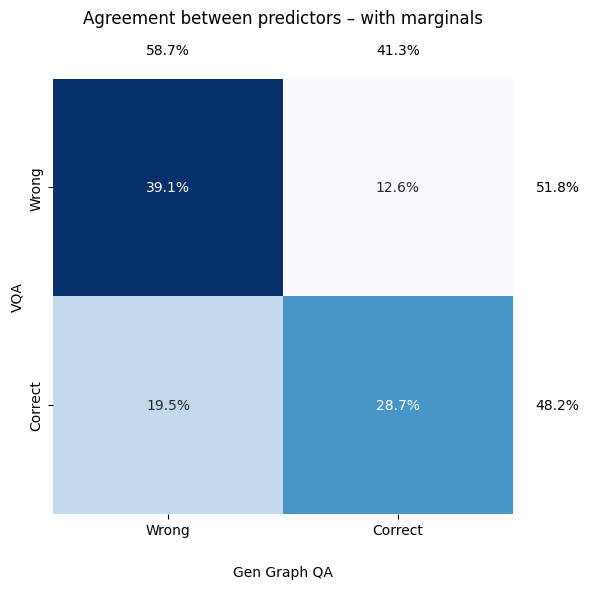

In [67]:
# your data
display_eval = eval_df_all
pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_gg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# annotate row marginals at the right of each row
for i, p in enumerate(row_pct):
    ax.text(len(labels) + 0.1,  i + 0.5, f'{p:.1%}', 
            va='center', ha='left', fontsize=10)

# annotate column marginals just above each column
for j, p in enumerate(col_pct):
    ax.text(j + 0.5, -0.1, f'{p:.1%}', 
            ha='center', va='bottom', fontsize=10)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Gen Graph QA', labelpad=20)
ax.set_ylabel('VQA')
ax.set_title('Agreement between predictors – with marginals', pad=40)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()


The graph above tell us the following insights:
- In ~20% the samples the VQA is able to guess the right response where the Graph based QA mistakes
- On the other hand, there's a significant 12% where the Graph based QA is correct and the VQA is wrong


In [68]:
vqa_correct_gg_wrong = pred_vqa_correct & ~pred_gg_correct
mask = vqa_correct_gg_wrong.astype(bool)


In [69]:
indices = eval_df_all[mask].index
test1 = indices[0]


In [70]:
qa_viz.compact_print_qa(
    test1, gt_df.rename(columns={'text': 'answer'}),
    [pred_vqa_df.rename(columns={'pred_text1': 'answer'}), pred_gg_df.rename(columns={'pred_text2': 'answer'})],
    ['VQA', 'GG-QA'])



┌─ Sample: Feasibility_T5_1851 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object is the person able to close after taking the cup/glass/bottle?
│ Alternatives:
│    0. The door.
│    1. The book.
│    2. The laptop.
│    3. The closet/cabinet.
│
│ Ground Truth:
│    The laptop.
│
|
│ Model Predictions - VQA:
│    Prediction:  the laptop. [CORRECT]
│    Reasoning:
│        Okay, let’s analyze the video and respond to the question.
│        
│        **1. Question Interpretation:** The question asks which object the person is able to close after taking a drink from a cup/glass/bottle.
│        
│        **2. Video Analysis:**
│        
│        *   **Person:** The video shows a man sitting in a wheelchair. He is actively drinking from a cup/bottle.
│        *   **Objects in the Scene:** The scene contains a table with various items: a laptop, a Reese’s cup, a bottle of ketchup, a bottle of mustard, a bottle of mayonnaise, a book, and a cabinet

In [71]:
test1 = indices[1]
qa_viz.compact_print_qa(
    test1, gt_df.rename(columns={'text': 'answer'}),
    [pred_vqa_df.rename(columns={'pred_text1': 'answer'}), pred_gg_df.rename(columns={'pred_text2': 'answer'})],
    ['VQA', 'GG-QA'])



┌─ Sample: Prediction_T4_1828 ──────────────────────────────────────────────────────────────
│
│ Question:
│    Which object would the person close next after they hold the dish?
│ Alternatives:
│    0. The box.
│    1. The closet/cabinet.
│    2. The door.
│    3. The refrigerator.
│
│ Ground Truth:
│    The refrigerator.
│
|
│ Model Predictions - VQA:
│    Prediction:  The refrigerator. [CORRECT]
│    Reasoning:
│        Okay, let’s analyze the video and respond to the question.
│        
│        **1. Question Interpretation:** The question asks which object the person will close *after* they hold the dish. It’s a sequential question, requiring us to observe the person’s actions in order.
│        
│        **2. Video Analysis:**
│        
│        *   **Person:** A man is standing in a kitchen. He’s wearing a long-sleeved shirt.
│        *   **Dish:** He is holding a red pot.
│        *   **Refrigerator:** He is moving towards the refrigerator.
│        *   **Cabinet/Closet:** The

In [72]:
test1 = indices[2]
qa_viz.compact_print_qa(
    test1, gt_df.rename(columns={'text': 'answer'}),
    [pred_vqa_df.rename(columns={'pred_text1': 'answer'}), pred_gg_df.rename(columns={'pred_text2': 'answer'})],
    ['VQA', 'GG-QA'])



┌─ Sample: Prediction_T4_1805 ──────────────────────────────────────────────────────────────
│
│ Question:
│    Which object would the person close next after they hold the dish?
│ Alternatives:
│    0. The closet/cabinet.
│    1. The door.
│    2. The laptop.
│    3. The box.
│
│ Ground Truth:
│    The closet/cabinet.
│
|
│ Model Predictions - VQA:
│    Prediction:  The closet/cabinet. [CORRECT]
│    Reasoning:
│        Okay, let’s analyze the video and respond to the question.
│        
│        **1. Question Interpretation:** The question asks what object the person will likely interact with *next* after they are seen holding a dish.
│        
│        **2. Video Analysis:**
│        
│        The video shows a person wearing a maroon shirt with “PAL” written on the back, standing at a kitchen sink. They are holding a dish and appear to be washing it. The sink is full of dirty dishes. There’s a cabinet/closet visible above the sink, a refrigerator to the right, and a few other item

## Inspecting the performance of VQA on previously inspected samples


In [73]:
prev_analyzed = [
    "Interaction_T1_4054",
    "Interaction_T1_8913",
    "Interaction_T2_3423",
    "Interaction_T1_4115",
    "Interaction_T1_1168",
    "Interaction_T1_309",
    "Interaction_T1_4703",
    "Interaction_T1_2516",
    "Interaction_T1_8967",
    "Interaction_T1_5709",
    "Interaction_T1_2226",
    "Interaction_T1_111",
    "Interaction_T1_8274",
    "Interaction_T1_7254",
    "Interaction_T1_4221",
    #"Interaction_T1_3485",
    #"Interaction_T4_4181",
    #"Interaction_T2_1847",
]


In [74]:
pred_gg_df = rp.gemma3_ans_extract(QA_GEN_GRAPHS_MAN_INSPECTION)


Total answers: 1694
Answers following JSON template: 1694
Percentage following JSON template: 100.00%
Answer following the template: 1246
73.55% of the total

Only 448 samples do not contain the answer in the response with the specified format


/home/lusha/star_code/src/response_processing.py:179: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


In [75]:
pred_gg_df.rename(columns={'answer': 'pred_text2'}, inplace=True)
eval_df_all = gt_df.join(
    pred_vqa_df[['pred_text1']],
    how='inner'
).join(
    pred_gg_df[['pred_text2']],
    how='inner'
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()


In [100]:
indices


Index(['Interaction_T1_4054', 'Interaction_T1_8913', 'Interaction_T2_3423',
       'Interaction_T1_4115', 'Interaction_T1_1168', 'Interaction_T1_309',
       'Interaction_T1_4703', 'Interaction_T1_2516', 'Interaction_T1_8967',
       'Interaction_T1_5709', 'Interaction_T1_2226', 'Interaction_T1_111',
       'Interaction_T1_8274', 'Interaction_T1_7254', 'Interaction_T1_4221'],
      dtype='object')

In [101]:
(display_eval.loc['Interaction_T1_8913']['text'] == display_eval.loc['Interaction_T1_8913']['pred_text1'])


True

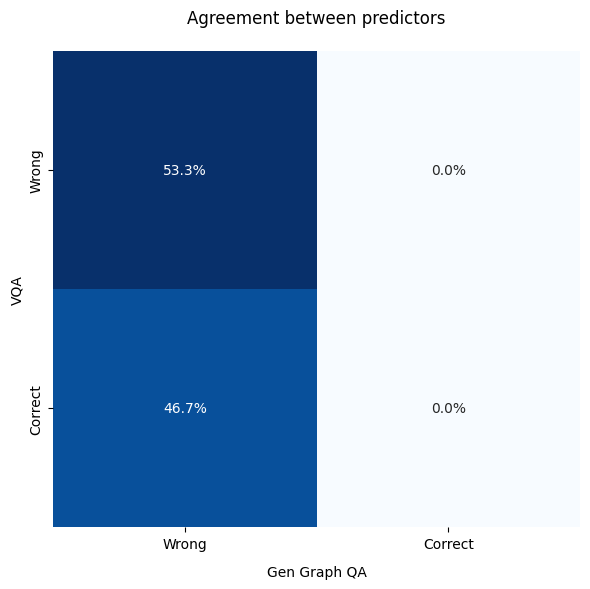

In [76]:
display_eval = eval_df_all.loc[prev_analyzed]

pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_gg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Gen Graph QA', labelpad=10)
ax.set_ylabel('VQA')
ax.set_title('Agreement between predictors', pad=20)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()


In [77]:
vqa_correct_gg_wrong = pred_vqa_correct & ~pred_gg_correct
mask = vqa_correct_gg_wrong.astype(bool)
indices = display_eval[mask].index



In [78]:
test1 = indices[0]
qa_viz.compact_print_qa(
    test1, gt_df.rename(columns={'text': 'answer'}),
    [pred_vqa_df.rename(columns={'pred_text1': 'answer'}), pred_gg_df.rename(columns={'pred_text2': 'answer'})],
    ['VQA', 'GG-QA'])



┌─ Sample: Interaction_T1_8913 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was taken by the person?
│ Alternatives:
│    0. The paper/notebook.
│    1. The laptop.
│    2. The bag.
│    3. The cup/glass/bottle.
│
│ Ground Truth:
│    The paper/notebook.
│
|
│ Model Predictions - VQA:
│    Prediction:  The paper/notebook. [CORRECT]
│    Reasoning:
│        Okay, let's analyze the video and answer the question.
│        
│        **1. Question Interpretation:** The question asks “Which object was taken by the person?” This means we need to identify what the person is holding or interacting with in the video.
│        
│        **2. Video Analysis:**
│        *   **Frame 1-4:** The person is sitting at a desk with a laptop. They are holding a paper/notebook. They appear to be writing on it.
│        *   **Frame 5-6:** The person continues to hold the paper/notebook.
│        *   **Frame 7-8:** The person is still holding the paper/noteboo

In [79]:
test1 = indices[1]
qa_viz.compact_print_qa(
    test1, gt_df.rename(columns={'text': 'answer'}),
    [pred_vqa_df.rename(columns={'pred_text1': 'answer'}), pred_gg_df.rename(columns={'pred_text2': 'answer'})],
    ['VQA', 'GG-QA'])



┌─ Sample: Interaction_T2_3423 ─────────────────────────────────────────────────────────────
│
│ Question:
│    What did the person do with the bed?
│ Alternatives:
│    0. Sat on.
│    1. Closed.
│    2. Lied on.
│    3. Washed.
│
│ Ground Truth:
│    Lied on.
│
|
│ Model Predictions - VQA:
│    Prediction:  Lied on. [CORRECT]
│    Reasoning:
│        Okay, let's analyze the video and answer the question.
│        
│        **1. Question Interpretation:** The question asks what the person was doing with the bed. It’s seeking a description of the person’s interaction with the bed.
│        
│        **2. Video Analysis:**
│        *   **Person:** A young child is lying on the bed. They are partially covered by the bedclothes. They appear to be relaxed, possibly resting or sleeping.
│        *   **Bed:** The bed is covered with a patterned quilt. The bed is the central element of the scene.
│        *   **Interaction:** The child is lying *on* the bed. They are not sitting on it, closi

In [ ]:
qaviz.Vis_Video(
    {"question_id": test1, **gt_df.loc[test1].to_dict()},
    RAW_VIDEO_DIR,
    SAVE_VIDEO_DIR)


Sat on is an acceptable answer for the video in question. Therefore the GGQ Answer can't be considered wrong.

In [81]:
test1 = indices[2]
qa_viz.compact_print_qa(
    test1, gt_df.rename(columns={'text': 'answer'}),
    [pred_vqa_df.rename(columns={'pred_text1': 'answer'}), pred_gg_df.rename(columns={'pred_text2': 'answer'})],
    ['VQA', 'GG-QA'])



┌─ Sample: Interaction_T1_4115 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was put down by the person?
│ Alternatives:
│    0. The pillow.
│    1. The box.
│    2. The laptop.
│    3. The sandwich.
│
│ Ground Truth:
│    The laptop.
│
|
│ Model Predictions - VQA:
│    Prediction:  The laptop. [CORRECT]
│    Reasoning:
│        Okay, let’s analyze the video and answer the question.
│        
│        **1. Question Interpretation:** The question asks: “Which object was put down by the person?”
│        
│        **2. Video Analysis:**
│        *   **Frame 1 & 2:** A person is sitting on a couch, using a laptop. They are holding the laptop with their hands.
│        *   **Frame 3 & 4:** The person is now standing up and appears to be placing the laptop down on the couch.
│        
│        **3. Alternative Evaluation:**
│        
│        *   **A. The pillow:** The pillow is visible in the first frames, but the person is not interacting w

In [82]:
qaviz.Vis_Video(
    {"question_id": test1, **gt_df.loc[test1].to_dict()},
    RAW_VIDEO_DIR,
    SAVE_VIDEO_DIR)


	Video Seg:  14.6s - 19.7s


ffmpeg version 4.3 Copyright (c) 2000-2020 the FFmpeg developers
  built with gcc 7.3.0 (crosstool-NG 1.23.0.449-a04d0)
  configuration: --prefix=/opt/conda/conda-bld/ffmpeg_1597178665428/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placeh --cc=/opt/conda/conda-bld/ffmpeg_1597178665428/_build_env/bin/x86_64-conda_cos6-linux-gnu-cc --disable-doc --disable-openssl --enable-avresample --enable-gnutls --enable-hardcoded-tables --enable-libfreetype --enable-libopenh264 --enable-pic --enable-pthreads --enable-shared --disable-static --enable-version3 --enable-zlib --enable-libmp3lame
  libavutil      56. 51.100 / 56. 51.100
  libavcodec     58. 91.100 / 58. 91.100
  libavformat    58. 45.100 / 58. 45.100
  libavdevice    58. 10.100 / 58. 10.100
  libavfilter     7. 85.100 /  7. 85.100
  libavresample   4.  0.  0 /  4.  0.  0
  libsw

In [83]:
test1 = indices[3]
qa_viz.compact_print_qa(
    test1, gt_df.rename(columns={'text': 'answer'}),
    [pred_vqa_df.rename(columns={'pred_text1': 'answer'}), pred_gg_df.rename(columns={'pred_text2': 'answer'})],
    ['VQA', 'GG-QA'])



┌─ Sample: Interaction_T1_1168 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was taken by the person?
│ Alternatives:
│    0. The phone/camera.
│    1. The food.
│    2. The laptop.
│    3. The bag.
│
│ Ground Truth:
│    The phone/camera.
│
|
│ Model Predictions - VQA:
│    Prediction:  the phone/camera. [CORRECT]
│    Reasoning:
│        Okay, let’s analyze the video and answer the question.
│        
│        **1. Question Interpretation:** The question asks: “Which object was taken by the person?”
│        
│        **2. Video Analysis:**
│        
│        The video shows a person sitting on a bed, with a dog beside them. The person is holding a small, rectangular object in their hands. It appears to be a phone or camera. The person is looking at the object and manipulating it with their hands. The object is held in a way that suggests it’s being used – likely to take a photo or video. The person is clearly interacting with the obje

In [84]:
qaviz.Vis_Video(
    {"question_id": test1, **gt_df.loc[test1].to_dict()},
    RAW_VIDEO_DIR,
    SAVE_VIDEO_DIR)


	Video Seg:  0.0s - 3.1s


ffmpeg version 4.3 Copyright (c) 2000-2020 the FFmpeg developers
  built with gcc 7.3.0 (crosstool-NG 1.23.0.449-a04d0)
  configuration: --prefix=/opt/conda/conda-bld/ffmpeg_1597178665428/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placeh --cc=/opt/conda/conda-bld/ffmpeg_1597178665428/_build_env/bin/x86_64-conda_cos6-linux-gnu-cc --disable-doc --disable-openssl --enable-avresample --enable-gnutls --enable-hardcoded-tables --enable-libfreetype --enable-libopenh264 --enable-pic --enable-pthreads --enable-shared --disable-static --enable-version3 --enable-zlib --enable-libmp3lame
  libavutil      56. 51.100 / 56. 51.100
  libavcodec     58. 91.100 / 58. 91.100
  libavformat    58. 45.100 / 58. 45.100
  libavdevice    58. 10.100 / 58. 10.100
  libavfilter     7. 85.100 /  7. 85.100
  libavresample   4.  0.  0 /  4.  0.  0
  libsw

In [85]:
test1 = indices[4]
qa_viz.compact_print_qa(
    test1, gt_df.rename(columns={'text': 'answer'}),
    [pred_vqa_df.rename(columns={'pred_text1': 'answer'}), pred_gg_df.rename(columns={'pred_text2': 'answer'})],
    ['VQA', 'GG-QA'])



┌─ Sample: Interaction_T1_5709 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was put down by the person?
│ Alternatives:
│    0. The bag.
│    1. The food.
│    2. The laptop.
│    3. The cup/glass/bottle.
│
│ Ground Truth:
│    The bag.
│
|
│ Model Predictions - VQA:
│    Prediction:  The bag. [CORRECT]
│    Reasoning:
│        Okay, let's analyze the video and answer the question.
│        
│        **1. Question Interpretation:** The question asks: “Which object was put down by the person?”
│        
│        **2. Video Analysis:**
│        I’ve reviewed the image. A person is standing in a kitchen. They are holding a bag. The bag is being lowered or placed down. It’s difficult to determine exactly *where* it’s being placed, but it’s clearly being lowered.
│        
│        **3. Alternative Evaluation:**
│        
│        *   **A. The bag:** This is the most likely answer. The video clearly shows the person lowering the bag.
│      

In [86]:
qaviz.Vis_Video(
    {"question_id": test1, **gt_df.loc[test1].to_dict()},
    RAW_VIDEO_DIR,
    SAVE_VIDEO_DIR)


	Video Seg:  1.7s - 10.7s


ffmpeg version 4.3 Copyright (c) 2000-2020 the FFmpeg developers
  built with gcc 7.3.0 (crosstool-NG 1.23.0.449-a04d0)
  configuration: --prefix=/opt/conda/conda-bld/ffmpeg_1597178665428/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placeh --cc=/opt/conda/conda-bld/ffmpeg_1597178665428/_build_env/bin/x86_64-conda_cos6-linux-gnu-cc --disable-doc --disable-openssl --enable-avresample --enable-gnutls --enable-hardcoded-tables --enable-libfreetype --enable-libopenh264 --enable-pic --enable-pthreads --enable-shared --disable-static --enable-version3 --enable-zlib --enable-libmp3lame
  libavutil      56. 51.100 / 56. 51.100
  libavcodec     58. 91.100 / 58. 91.100
  libavformat    58. 45.100 / 58. 45.100
  libavdevice    58. 10.100 / 58. 10.100
  libavfilter     7. 85.100 /  7. 85.100
  libavresample   4.  0.  0 /  4.  0.  0
  libsw

In [99]:
vqa_correct_gg_wrong = (~pred_vqa_correct) & (~pred_gg_correct)
mask = vqa_correct_gg_wrong.astype(bool)
indices = display_eval[mask].index



In [97]:
indices


Index(['Interaction_T1_4054', 'Interaction_T1_8913', 'Interaction_T2_3423',
       'Interaction_T1_4115', 'Interaction_T1_1168', 'Interaction_T1_309',
       'Interaction_T1_4703', 'Interaction_T1_2516', 'Interaction_T1_8967',
       'Interaction_T1_5709', 'Interaction_T1_2226', 'Interaction_T1_111',
       'Interaction_T1_8274', 'Interaction_T1_7254', 'Interaction_T1_4221'],
      dtype='object')

In [88]:
test1 = indices[0]
qa_viz.compact_print_qa(
    test1, gt_df.rename(columns={'text': 'answer'}),
    [pred_vqa_df.rename(columns={'pred_text1': 'answer'}), pred_gg_df.rename(columns={'pred_text2': 'answer'})],
    ['VQA', 'GG-QA'])



┌─ Sample: Interaction_T1_4054 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was opened by the person?
│ Alternatives:
│    0. The bag.
│    1. The closet/cabinet.
│    2. The refrigerator.
│    3. The laptop.
│
│ Ground Truth:
│    The closet/cabinet.
│
|
│ Model Predictions - VQA:
│    Prediction:  The bag. [WRONG]
│    Reasoning:
│        Okay, let’s analyze the video and respond to the question.
│        
│        **1. Question Interpretation:** The question asks: “Which object was opened by the person?” This implies we need to identify what the person is interacting with and potentially manipulating to open something.
│        
│        **2. Video Analysis:**
│        
│        *   **Recurring Objects:** The most prominent recurring object is a large, dark-colored plush toy (likely a bear) that the person is holding and interacting with. There’s also a bed, a small table with a red object (possibly a drink or item), and a green pill

In [89]:
qaviz.Vis_Video(
    {"question_id": test1, **gt_df.loc[test1].to_dict()},
    RAW_VIDEO_DIR,
    SAVE_VIDEO_DIR)


	Video Seg:  6.0s - 13.0s


ffmpeg version 4.3 Copyright (c) 2000-2020 the FFmpeg developers
  built with gcc 7.3.0 (crosstool-NG 1.23.0.449-a04d0)
  configuration: --prefix=/opt/conda/conda-bld/ffmpeg_1597178665428/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placeh --cc=/opt/conda/conda-bld/ffmpeg_1597178665428/_build_env/bin/x86_64-conda_cos6-linux-gnu-cc --disable-doc --disable-openssl --enable-avresample --enable-gnutls --enable-hardcoded-tables --enable-libfreetype --enable-libopenh264 --enable-pic --enable-pthreads --enable-shared --disable-static --enable-version3 --enable-zlib --enable-libmp3lame
  libavutil      56. 51.100 / 56. 51.100
  libavcodec     58. 91.100 / 58. 91.100
  libavformat    58. 45.100 / 58. 45.100
  libavdevice    58. 10.100 / 58. 10.100
  libavfilter     7. 85.100 /  7. 85.100
  libavresample   4.  0.  0 /  4.  0.  0
  libsw

In [95]:
display_eval.loc[test1]


question                        Which object was taken by the person?
video_id                                                        F9YMU
start                                                            11.9
end                                                              16.5
text                                              the paper/notebook.
question_program    [{'function': 'Situations', 'value_input': []}...
choices             [{'choice_id': 0, 'choice': 'The paper/noteboo...
situations          {'000213': {'rel_pairs': [['o000', 'o006'], ['...
pred_text1                                        the paper/notebook.
pred_text2                                                   the bag.
Name: Interaction_T1_8913, dtype: object

In [94]:
pred_vqa_df.loc[test1]


pred_text1                                    The paper/notebook.
chat_history    [{'role': 'user', 'content': 'You are an intel...
Name: Interaction_T1_8913, dtype: object

In [93]:
test1 = indices[1]
qa_viz.compact_print_qa(
    test1, gt_df.rename(columns={'text': 'answer'}),
    [pred_vqa_df.rename(columns={'pred_text1': 'answer'}), pred_gg_df.rename(columns={'pred_text2': 'answer'})],
    ['VQA', 'GG-QA'])



┌─ Sample: Interaction_T1_8913 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was taken by the person?
│ Alternatives:
│    0. The paper/notebook.
│    1. The laptop.
│    2. The bag.
│    3. The cup/glass/bottle.
│
│ Ground Truth:
│    The paper/notebook.
│
|
│ Model Predictions - VQA:
│    Prediction:  The paper/notebook. [CORRECT]
│    Reasoning:
│        Okay, let's analyze the video and answer the question.
│        
│        **1. Question Interpretation:** The question asks “Which object was taken by the person?” This means we need to identify what the person is holding or interacting with in the video.
│        
│        **2. Video Analysis:**
│        *   **Frame 1-4:** The person is sitting at a desk with a laptop. They are holding a paper/notebook. They appear to be writing on it.
│        *   **Frame 5-6:** The person continues to hold the paper/notebook.
│        *   **Frame 7-8:** The person is still holding the paper/noteboo

In [49]:
qaviz.Vis_Video(
    {"question_id": test1, **gt_df.loc[test1].to_dict()},
    RAW_VIDEO_DIR,
    SAVE_VIDEO_DIR)


	Video Seg:  11.9s - 16.5s


ffmpeg version 4.3 Copyright (c) 2000-2020 the FFmpeg developers
  built with gcc 7.3.0 (crosstool-NG 1.23.0.449-a04d0)
  configuration: --prefix=/opt/conda/conda-bld/ffmpeg_1597178665428/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placeh --cc=/opt/conda/conda-bld/ffmpeg_1597178665428/_build_env/bin/x86_64-conda_cos6-linux-gnu-cc --disable-doc --disable-openssl --enable-avresample --enable-gnutls --enable-hardcoded-tables --enable-libfreetype --enable-libopenh264 --enable-pic --enable-pthreads --enable-shared --disable-static --enable-version3 --enable-zlib --enable-libmp3lame
  libavutil      56. 51.100 / 56. 51.100
  libavcodec     58. 91.100 / 58. 91.100
  libavformat    58. 45.100 / 58. 45.100
  libavdevice    58. 10.100 / 58. 10.100
  libavfilter     7. 85.100 /  7. 85.100
  libavresample   4.  0.  0 /  4.  0.  0
  libsw

Sat on is an acceptable answer for the video in question. Therefore the GGQ Answer can't be considered wrong.

In [50]:
test1 = indices[2]
qa_viz.compact_print_qa(
    test1, gt_df.rename(columns={'text': 'answer'}),
    [pred_vqa_df.rename(columns={'pred_text1': 'answer'}), pred_gg_df.rename(columns={'pred_text2': 'answer'})],
    ['VQA', 'GG-QA'])



┌─ Sample: Interaction_T2_3423 ─────────────────────────────────────────────────────────────
│
│ Question:
│    What did the person do with the bed?
│ Alternatives:
│    0. Sat on.
│    1. Closed.
│    2. Lied on.
│    3. Washed.
│
│ Ground Truth:
│    Lied on.
│
|
│ Model Predictions - VQA:
│    Prediction:  Lied on. [CORRECT]
│    Reasoning:
│        Okay, let's analyze the video and answer the question.
│        
│        **1. Question Interpretation:** The question asks what the person was doing with the bed. It’s seeking a description of the person’s interaction with the bed.
│        
│        **2. Video Analysis:**
│        *   **Person:** A young child is lying on the bed. They are partially covered by the bedclothes. They appear to be relaxed, possibly resting or sleeping.
│        *   **Bed:** The bed is covered with a patterned quilt. The bed is the central element of the scene.
│        *   **Interaction:** The child is lying *on* the bed. They are not sitting on it, closi

In [51]:
qaviz.Vis_Video(
    {"question_id": test1, **gt_df.loc[test1].to_dict()},
    RAW_VIDEO_DIR,
    SAVE_VIDEO_DIR)


	Video Seg:  0.0s - 6.8s


ffmpeg version 4.3 Copyright (c) 2000-2020 the FFmpeg developers
  built with gcc 7.3.0 (crosstool-NG 1.23.0.449-a04d0)
  configuration: --prefix=/opt/conda/conda-bld/ffmpeg_1597178665428/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placeh --cc=/opt/conda/conda-bld/ffmpeg_1597178665428/_build_env/bin/x86_64-conda_cos6-linux-gnu-cc --disable-doc --disable-openssl --enable-avresample --enable-gnutls --enable-hardcoded-tables --enable-libfreetype --enable-libopenh264 --enable-pic --enable-pthreads --enable-shared --disable-static --enable-version3 --enable-zlib --enable-libmp3lame
  libavutil      56. 51.100 / 56. 51.100
  libavcodec     58. 91.100 / 58. 91.100
  libavformat    58. 45.100 / 58. 45.100
  libavdevice    58. 10.100 / 58. 10.100
  libavfilter     7. 85.100 /  7. 85.100
  libavresample   4.  0.  0 /  4.  0.  0
  libsw

In [52]:
test1 = indices[3]
qa_viz.compact_print_qa(
    test1, gt_df.rename(columns={'text': 'answer'}),
    [pred_vqa_df.rename(columns={'pred_text1': 'answer'}), pred_gg_df.rename(columns={'pred_text2': 'answer'})],
    ['VQA', 'GG-QA'])



┌─ Sample: Interaction_T1_4115 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was put down by the person?
│ Alternatives:
│    0. The pillow.
│    1. The box.
│    2. The laptop.
│    3. The sandwich.
│
│ Ground Truth:
│    The laptop.
│
|
│ Model Predictions - VQA:
│    Prediction:  The laptop. [CORRECT]
│    Reasoning:
│        Okay, let’s analyze the video and answer the question.
│        
│        **1. Question Interpretation:** The question asks: “Which object was put down by the person?”
│        
│        **2. Video Analysis:**
│        *   **Frame 1 & 2:** A person is sitting on a couch, using a laptop. They are holding the laptop with their hands.
│        *   **Frame 3 & 4:** The person is now standing up and appears to be placing the laptop down on the couch.
│        
│        **3. Alternative Evaluation:**
│        
│        *   **A. The pillow:** The pillow is visible in the first frames, but the person is not interacting w

In [53]:
qaviz.Vis_Video(
    {"question_id": test1, **gt_df.loc[test1].to_dict()},
    RAW_VIDEO_DIR,
    SAVE_VIDEO_DIR)


	Video Seg:  14.6s - 19.7s


ffmpeg version 4.3 Copyright (c) 2000-2020 the FFmpeg developers
  built with gcc 7.3.0 (crosstool-NG 1.23.0.449-a04d0)
  configuration: --prefix=/opt/conda/conda-bld/ffmpeg_1597178665428/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placeh --cc=/opt/conda/conda-bld/ffmpeg_1597178665428/_build_env/bin/x86_64-conda_cos6-linux-gnu-cc --disable-doc --disable-openssl --enable-avresample --enable-gnutls --enable-hardcoded-tables --enable-libfreetype --enable-libopenh264 --enable-pic --enable-pthreads --enable-shared --disable-static --enable-version3 --enable-zlib --enable-libmp3lame
  libavutil      56. 51.100 / 56. 51.100
  libavcodec     58. 91.100 / 58. 91.100
  libavformat    58. 45.100 / 58. 45.100
  libavdevice    58. 10.100 / 58. 10.100
  libavfilter     7. 85.100 /  7. 85.100
  libavresample   4.  0.  0 /  4.  0.  0
  libsw

In [54]:
test1 = indices[4]
qa_viz.compact_print_qa(
    test1, gt_df.rename(columns={'text': 'answer'}),
    [pred_vqa_df.rename(columns={'pred_text1': 'answer'}), pred_gg_df.rename(columns={'pred_text2': 'answer'})],
    ['VQA', 'GG-QA'])



┌─ Sample: Interaction_T1_1168 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was taken by the person?
│ Alternatives:
│    0. The phone/camera.
│    1. The food.
│    2. The laptop.
│    3. The bag.
│
│ Ground Truth:
│    The phone/camera.
│
|
│ Model Predictions - VQA:
│    Prediction:  the phone/camera. [CORRECT]
│    Reasoning:
│        Okay, let’s analyze the video and answer the question.
│        
│        **1. Question Interpretation:** The question asks: “Which object was taken by the person?”
│        
│        **2. Video Analysis:**
│        
│        The video shows a person sitting on a bed, with a dog beside them. The person is holding a small, rectangular object in their hands. It appears to be a phone or camera. The person is looking at the object and manipulating it with their hands. The object is held in a way that suggests it’s being used – likely to take a photo or video. The person is clearly interacting with the obje

In [55]:
qaviz.Vis_Video(
    {"question_id": test1, **gt_df.loc[test1].to_dict()},
    RAW_VIDEO_DIR,
    SAVE_VIDEO_DIR)


	Video Seg:  0.0s - 3.1s


ffmpeg version 4.3 Copyright (c) 2000-2020 the FFmpeg developers
  built with gcc 7.3.0 (crosstool-NG 1.23.0.449-a04d0)
  configuration: --prefix=/opt/conda/conda-bld/ffmpeg_1597178665428/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placeh --cc=/opt/conda/conda-bld/ffmpeg_1597178665428/_build_env/bin/x86_64-conda_cos6-linux-gnu-cc --disable-doc --disable-openssl --enable-avresample --enable-gnutls --enable-hardcoded-tables --enable-libfreetype --enable-libopenh264 --enable-pic --enable-pthreads --enable-shared --disable-static --enable-version3 --enable-zlib --enable-libmp3lame
  libavutil      56. 51.100 / 56. 51.100
  libavcodec     58. 91.100 / 58. 91.100
  libavformat    58. 45.100 / 58. 45.100
  libavdevice    58. 10.100 / 58. 10.100
  libavfilter     7. 85.100 /  7. 85.100
  libavresample   4.  0.  0 /  4.  0.  0
  libsw